**ANOMALY DETECTION**

In [1]:
import digitalhub as dh
import zipfile
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PROJECT_NAME = "floods"
project = dh.get_project(PROJECT_NAME)
print(f"Project: {project.name}")

Project: floods


**SETUP PARAMETERS**

In [2]:
job_name = "net_v3"                                    
dataset_standard = "Standard" 
dataset_anomalies = "Floods_Anomalies_test_crop_norm"
moco_version = "net_v3"

parameters = {
    "job_name": job_name,                         # job_name del TRAINING MoCo da valutare
    "dataset_standard": dataset_standard,
    "dataset_anomalies": dataset_anomalies,         # split della cache Floods_Anomalies_{split}_crop_norm
    "moco_version": moco_version,   
    "simple_proj": False,                           # questi 6 devono essere identici a quelli del training,
    "attn": False,                                  # altrimenti load_state_dict fallisce per shape diverse
    "hidden_channels_dim": 64,
    "pool_grid": 4,
    
    "moco_dim": 128,
    "moco_k": 4096,
    "moco_m": 0.999,
    "moco_t": 0.07,
    "patch_size": 256,
    "n_images1": 4, "n_channels1": 2,       # sar
    "n_images2": 4, "n_channels2": 10,      # ottico
    "num_anomalies": 4974,
    "n_threshold_series": 5000,             # serie normali di TRAINING usate per stimare media e std della soglia
    "n_std": 1.0,                           # soglia = media +/- n_std * std (l'originale usa 1)
    "batch_size": 16,
    "workers": 0,                            
}

volumes = [
    {
        "volume_type": "ephemeral",
        "name": "volume-spazio-dati",
        "mount_path": "/data",      
        "spec": {"size": "500Gi"}   
    }
]

**BUILD ENVIRONMENT**

In [3]:
ad_train_func = project.new_function(
    name= f'anomalyDetection_{job_name}',
    kind="python",
    python_version="PYTHON3_10",
    code_src="../src/", 
    handler="train_anomaly_detection", 
    base_image="pytorch/pytorch:2.1.2-cuda11.8-cudnn8-runtime",
    requirements=["pandas==2.3.3", "numpy==1.26.4", "rasterio==1.4.4", "tqdm==4.70.0", "tifffile==2024.8.30", "torch==2.1.2", "matplotlib==3.10.9", "digitalhub==0.15.11", "digitalhub-runtime-python==0.15.2", "zarr==2.18.0", "numcodecs==0.13.1", "xarray==2025.6.1"]
)

build = ad_train_func.run("build", wait=True)
print(f"BUILD: {build.status.state}")

2026-09-30 05:35:03,096 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 9f6158aa36534a3693b4eb99c9f3c195 to finish...
2026-09-30 05:35:08,103 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 9f6158aa36534a3693b4eb99c9f3c195 to finish...
2026-09-30 05:35:13,113 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 9f6158aa36534a3693b4eb99c9f3c195 to finish...
2026-09-30 05:35:18,121 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 9f6158aa36534a3693b4eb99c9f3c195 to finish...
2026-09-30 05:35:23,130 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 9f6158aa36534a3693b4eb99c9f3c195 to finish...
2026-09-30 05:35:28,139 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 9f6158aa36534a3693b4eb99c9f3c195 to finish...
2026-09-30 05:35:33,149 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 9f6158aa36534a3693b4eb99c9f3c195 to finish...
2026-09-30 05

BUILD: COMPLETED


**TRAINING**

In [4]:
run_ad = ad_train_func.run(
    action="job", 
    parameters=parameters, 
    volumes=volumes, 
    profile="1xv100-shared",                                       
    local_execution= False,                                
    wait=True
)

print(f"Run train_encoders avviato: {run_ad.id}")

2026-09-30 05:35:53,352 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b3fa8b133e5e475eb3884be4653306d0 to finish...


2026-09-30 05:35:58,358 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b3fa8b133e5e475eb3884be4653306d0 to finish...
2026-09-30 05:36:03,367 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b3fa8b133e5e475eb3884be4653306d0 to finish...
2026-09-30 05:36:08,376 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b3fa8b133e5e475eb3884be4653306d0 to finish...
2026-09-30 05:36:13,387 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b3fa8b133e5e475eb3884be4653306d0 to finish...
2026-09-30 05:36:18,500 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b3fa8b133e5e475eb3884be4653306d0 to finish...
2026-09-30 05:36:23,509 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b3fa8b133e5e475eb3884be4653306d0 to finish...
2026-09-30 05:36:28,517 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b3fa8b133e5e475eb3884be4653306d0 to finish...
2026-09-30 05

Run train_encoders avviato: b3fa8b133e5e475eb3884be4653306d0


In [5]:
zip_path = project.get_artifact(f"anomaly_results_{job_name}").download("/tmp/anomaly_results.zip", overwrite=True)
with zipfile.ZipFile(zip_path) as z:
    z.extractall("/tmp/anomaly_results")

In [6]:
with open("/tmp/anomaly_results/anomaly_results.json") as f:
    results = json.load(f)

print(f"n_thr: {results['n_thr']} | n_normali: {results['n_normali']} | n_anomale: {results['n_anomale']}", "\n")
print(f"thr: media {results['thr']['mean']:.4f} ± {results['thr']['std']:.4f} -> [{results['thr']['thr_low']:.4f}, {results['thr']['thr_high']:.4f}]")
print(f"cos_sim normali: {results['cos_sim_normal']['mean']:.4f} ± {results['cos_sim_normal']['std']:.4f}")
print(f"cos_sim anomale: {results['cos_sim_anom']['mean']:.4f} ± {results['cos_sim_anom']['std']:.4f}", "\n")
print(f"AUROC (similarità alta = anomalia): {results['auroc_cos_sim_high_anom']:.3f}")
print(f"AUROC (similarità bassa = anomalia): {results['auroc_cos_sim_low_anom']:.3f}")

df_rules = pd.DataFrame(results['rules']).T
df_rules

n_thr: 5000 | n_normali: 4974 | n_anomale: 4974 

thr: media 0.4212 ± 0.1162 -> [0.3050, 0.5375]
cos_sim normali: 0.3594 ± 0.1305
cos_sim anomale: 0.2058 ± 0.1905 

AUROC (similarità alta = anomalia): 0.260
AUROC (similarità bassa = anomalia): 0.740


,TP,FP,FN,TN,FA_rate,MA_rate,REC,PREC,F1
cos_sim > m+1*std,136.0,450.0,4838.0,4524.0,0.09047,0.972658,0.027342,0.232082,0.048921
cos_sim < m-1*std,3367.0,1664.0,1607.0,3310.0,0.33454,0.323080,0.676920,0.669251,0.673063
m-1*std < cos_sim < m+1*std,3503.0,2114.0,1471.0,2860.0,0.42501,0.295738,0.704262,0.623643,0.661505


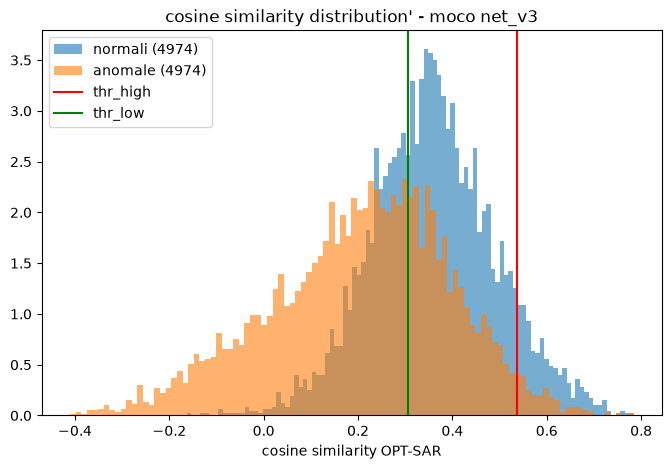

In [7]:
df = pd.read_csv("/tmp/anomaly_results/similarities.csv")
cos_sim_normal = df[df.label == 0]['similarity']
cos_sim_anom = df[df.label == 1]['similarity']

with open("/tmp/anomaly_results/anomaly_results.json") as f:
    results = json.load(f)
thr_high = results['thr']['thr_high']
thr_low = results['thr']['thr_low']

plt.figure(figsize=(8, 5))
plt.hist(cos_sim_normal, bins=100, alpha=0.6, density=True, label=f"normali ({len(cos_sim_normal)})")
plt.hist(cos_sim_anom, bins=100, alpha=0.6, density=True, label=f"anomale ({len(cos_sim_anom)})")
plt.axvline(x=thr_high, color='r', label='thr_high')
plt.axvline(x=thr_low, color='g', label='thr_low')
plt.xlabel("cosine similarity OPT-SAR")
plt.legend()
plt.title(f"cosine similarity distribution' - moco {results['job_name']}")
plt.show()

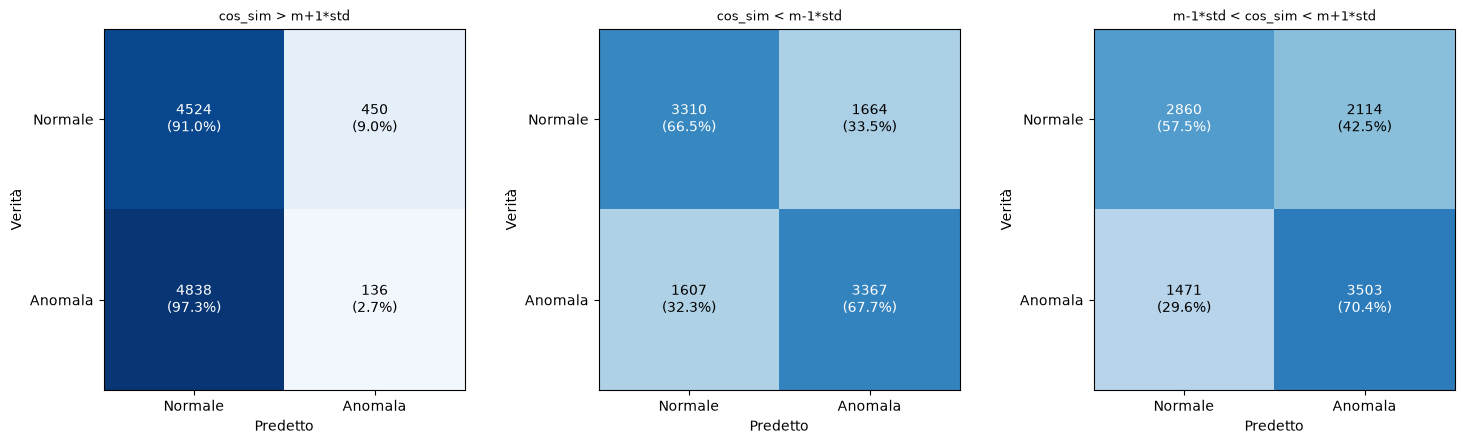

In [8]:
rules = results['rules']   
fig, axes = plt.subplots(1, len(rules), figsize=(5 * len(rules), 4.5))

for ax, (nome, r) in zip(axes, rules.items()):
    mat = np.array([[r["TN"], r["FP"]],
                     [r["FN"], r["TP"]]])
    mat_pct = mat / mat.sum(axis=1, keepdims=True) * 100   

    im = ax.imshow(mat_pct, cmap="Blues", vmin=0, vmax=100)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Normale", "Anomala"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Normale", "Anomala"])
    ax.set_xlabel("Predetto"); ax.set_ylabel("Verità")
    ax.set_title(nome, fontsize=9)

    for i in range(2):
        for j in range(2):
            color = "white" if mat_pct[i, j] > 55 else "black"
            ax.text(j, i, f"{int(mat[i, j])}\n({mat_pct[i, j]:.1f}%)",
                    ha="center", va="center", color=color, fontsize=10)

plt.tight_layout()
plt.show()